In [53]:
# 1 importar bibliotecas importantes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# 2 Carregar os dados
df = pd.read_excel('dados1.xlsx')

# 3 Converter a coluna 'horas' para o formato datetime
df['horas'] = pd.to_datetime(df['horas'], format='%H:%M:%S', errors='coerce')

# 4 Formata a coluna para mostrar apenas hora e minuto (HH:MM)
df['horas'] = df['horas'].dt.strftime('%H:%M')

In [3]:
# ver as primeiras 5 linhas
df.head()

,horas,Tipo_Secagem,a1,a2,a3,Humidade do ar,velocidade do vento,Radiação,Temp_foco,Temp_interna_receptor,...,Q_util2 (kJ),Q_util3 (kJ),efic_insta,h_conv,Q_conv (kJ),Q_rad (kJ),Q_perd (kJ),Tempo(s),Q_absorvido,efic_optica
0,09:31,Concentrador Solar Parabolico,45.5,46.0,46.0,41,2.42,881.00,114.00,54.00,...,0.000000,0.000000,0.000000,10.06,28.451290,0.037293,28.488582,1800.0,28.488582,2.541350
1,09:31,Natural,45.5,46.0,46.0,41,7.42,881.00,0.00,22.00,...,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10:08,Concentrador Solar Parabolico,45.5,46.0,46.0,29,1.72,899.06,136.08,54.72,...,0.957368,1.610118,0.140747,7.96,44.728835,0.078378,44.807213,3600.0,46.417331,4.057523
3,10:08,Natural,45.5,46.0,46.0,29,1.72,899.06,0.00,22.93,...,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10:47,Concentrador Solar Parabolico,45.0,45.5,45.5,25,3.95,905.81,149.94,90.44,...,0.914945,1.538771,0.133508,14.65,255.975436,0.900290,256.875726,5400.0,258.414496,22.420706


In [4]:
df.isnull().sum()

horas                     0
Tipo_Secagem              0
a1                       35
a2                       33
a3                        2
Humidade do ar            0
velocidade do vento       0
Radiação                  0
Temp_foco                 0
Temp_interna_receptor     0
Temp_ambiente             0
Q_solar (kJ)              0
Lv(T)(kJ)                 0
m(a1)                    49
m(a2)                    48
m(a3)                     2
Q_util1 (kJ)             49
Q_util2 (kJ)             48
Q_util3 (kJ)              2
efic_insta                2
h_conv                   33
Q_conv (kJ)              33
Q_rad (kJ)               33
Q_perd (kJ)              33
Tempo(s)                 33
Q_absorvido              33
efic_optica              33
dtype: int64

In [5]:
# 5 Separar dados por tipo de secagem
# ========================================
df_natural = df[df["Tipo_Secagem"] == "Natural"]
df_concentrador = df[df["Tipo_Secagem"] == "Concentrador Solar Parabolico"]

print(df_natural.columns)
print(df_concentrador.columns)

df_c = df_concentrador.copy()
df_n = df_natural.copy()

Index(['horas', 'Tipo_Secagem', 'a1', 'a2', 'a3', 'Humidade do ar',
       'velocidade do vento', 'Radiação', 'Temp_foco', 'Temp_interna_receptor',
       'Temp_ambiente', 'Q_solar (kJ)', 'Lv(T)(kJ)', 'm(a1)', 'm(a2)', 'm(a3)',
       'Q_util1 (kJ)', 'Q_util2 (kJ)', 'Q_util3 (kJ)', 'efic_insta', 'h_conv',
       'Q_conv (kJ)', 'Q_rad (kJ)', 'Q_perd (kJ)', 'Tempo(s)', 'Q_absorvido',
       'efic_optica'],
      dtype='object')
Index(['horas', 'Tipo_Secagem', 'a1', 'a2', 'a3', 'Humidade do ar',
       'velocidade do vento', 'Radiação', 'Temp_foco', 'Temp_interna_receptor',
       'Temp_ambiente', 'Q_solar (kJ)', 'Lv(T)(kJ)', 'm(a1)', 'm(a2)', 'm(a3)',
       'Q_util1 (kJ)', 'Q_util2 (kJ)', 'Q_util3 (kJ)', 'efic_insta', 'h_conv',
       'Q_conv (kJ)', 'Q_rad (kJ)', 'Q_perd (kJ)', 'Tempo(s)', 'Q_absorvido',
       'efic_optica'],
      dtype='object')


# GRAFICO I (condicoes climaticas)

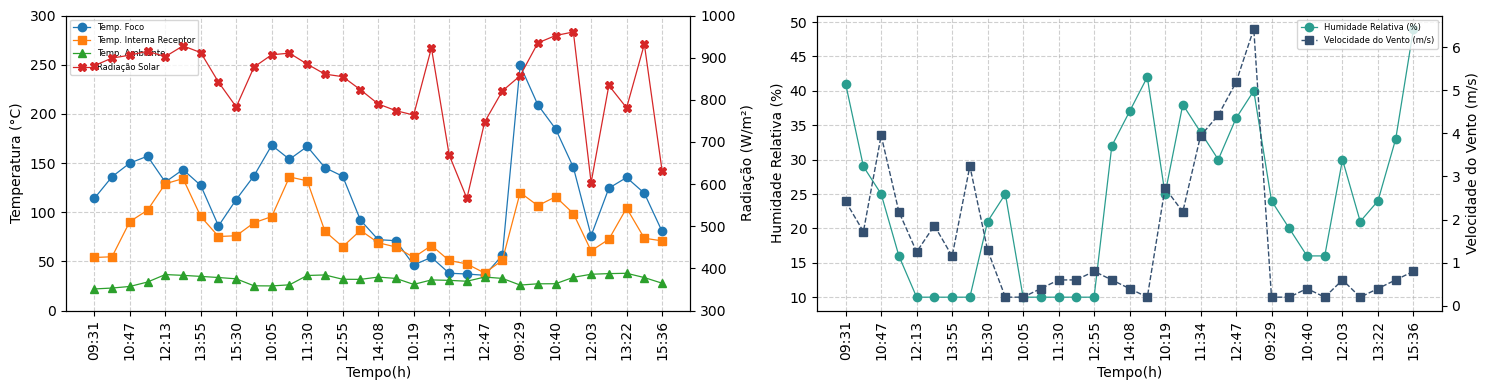

In [6]:
# Definir janela de suavização (ex: 3 pontos)
window = 1

# Suavizar os dados usando média móvel
Temp_foco_smooth = df_c["Temp_foco"].rolling(window=window, center=True).mean()
Temp_biomassa_smooth = df_c["Temp_interna_receptor"].rolling(window=window, center=True).mean()
Temp_amb_smooth = df_c["Temp_ambiente"].rolling(window=window, center=True).mean()
Rad_smooth = df_c["Radiação"].rolling(window=window, center=True).mean()
humid_smooth =  df_c["Humidade do ar"].rolling(window=window, center=True).mean()
Velo_smooth =  df_c["velocidade do vento"].rolling(window=window, center=True).mean()

# Criar figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
# === SUBPLOT 1: Temperaturas + Radiação ===
ax1 = axes[0]

# Eixo primário
ax1.plot(df_c["horas"], Temp_foco_smooth, label="Temp. Foco", marker="o", linewidth=0.9)
ax1.plot(df_c["horas"], Temp_biomassa_smooth, label="Temp. Interna Receptor", marker="s", linewidth=0.9)
ax1.plot(df_c["horas"], Temp_amb_smooth, label="Temp. Ambiente", marker="^", linewidth=0.9)

ax1.set_xlabel("Tempo(h)")
ax1.set_ylabel("Temperatura (°C)")
ax1.set_ylim(0, 300)
ax1.tick_params(axis='x', rotation=90)

# Eixo secundário
ax2 = ax1.twinx()
ax2.plot(df_c["horas"], Rad_smooth, color="C3", marker = 'X' , linewidth=0.9, label="Radiação Solar")
ax2.set_ylabel("Radiação (W/m²)")
ax2.set_ylim(300, 1000)

# Combinar legendas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left", fontsize=6)

#ax1.set_title("Temperaturas e Radiação Solar\n(Concentrador Solar Parabólico)")
ax1.set_xticks(df_c["horas"].iloc[::2])  # Pega de 2 em 2 registro
ax1.grid(True, linestyle="--", alpha=0.6)




# === SUBPLOT 2: Humidade Relativa + Velocidade do Vento ===
ax3 = axes[1]

# Eixo primário
ax3.plot(df_c["horas"], humid_smooth, color="#2A9D8F", marker="o", label="Humidade Relativa (%)", linewidth=0.9)
ax3.set_xlabel("Tempo(h)")
ax3.set_ylabel("Humidade Relativa (%)")
ax3.tick_params(axis="y")
ax3.tick_params(axis='x', rotation=90)

# Eixo secundário
ax4 = ax3.twinx()
ax4.plot(df_c["horas"], Velo_smooth, color="#355070", marker="s", linestyle="--", label="Velocidade do Vento (m/s)", linewidth=1)
ax4.set_ylabel("Velocidade do Vento (m/s)")
ax4.tick_params(axis="y")

# Combinar legendas
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc="upper right", fontsize=6)

#ax3.set_title("Humidade Relativa e Velocidade do Vento\n(Condições Meteorológicas)")
ax3.set_xticks(df_c["horas"].iloc[::2])  # Pega de 2 em 2 registros
ax3.grid(True, linestyle="--", alpha=0.6)


# Ajustar layout
plt.tight_layout()
#fig.savefig("Condicoes Clmimaticas.png", dpi=300)
plt.show()

# GRAFICO II (reducao da humidade)

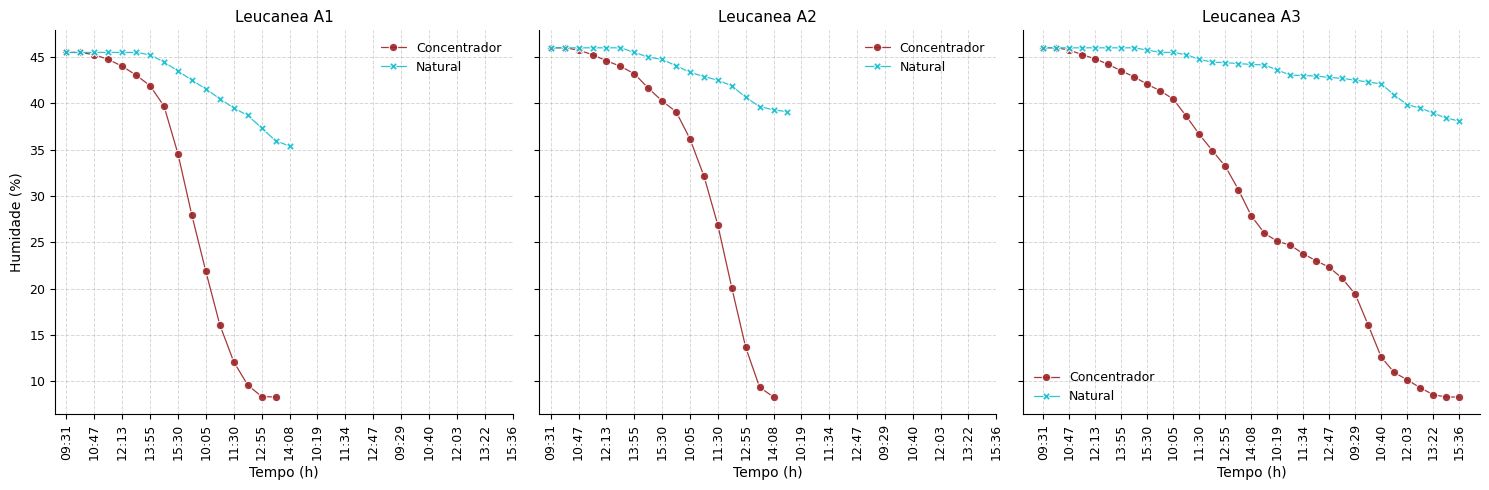

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker

# 1. Carregar os dados
df = pd.read_excel('dados1.xlsx')

# 2. Converter a coluna 'horas' para datetime
df['horas'] = pd.to_datetime(df['horas'], format='%H:%M:%S', errors='coerce')

# 3. Converter para string (HH:MM)
df['horas'] = df['horas'].dt.strftime('%H:%M')

# 4. Separar dados por tipo de secagem
df_n = df[df["Tipo_Secagem"] == "Natural"].copy()
df_c = df[df["Tipo_Secagem"] == "Concentrador Solar Parabolico"].copy()

# 5. Suavização (média móvel)
window = 2
for col in ["a1", "a2", "a3"]:
    df_n[col] = df_n[col].rolling(window=window, center=True, min_periods=1).mean()
    df_c[col] = df_c[col].rolling(window=window, center=True, min_periods=1).mean()

# 6. Criar figura
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
colors = {"Concentrador": "#9B2226" , "Natural": "#17becf"}

for i, amostra in enumerate(["a1", "a2", "a3"]):
    # Plotar curvas suavizadas com estilo elegante
    axes[i].plot(df_c["horas"], df_c[amostra],
                 color=colors["Concentrador"], linewidth=0.9,
                 marker="o", markersize=6, markerfacecolor=colors["Concentrador"],
                 markeredgecolor="white", markeredgewidth=0.8,
                 alpha=0.9, solid_capstyle='round', label="Concentrador")

    axes[i].plot(df_n["horas"], df_n[amostra],
                 color=colors["Natural"], linewidth=0.9,
                 marker="X", markersize=6, markerfacecolor=colors["Natural"],
                 markeredgecolor="white", markeredgewidth=0.8,
                 alpha=0.9, solid_capstyle='round', label="Natural")

    # Título e rótulos
    axes[i].set_title(f"Leucanea {amostra.upper()}",
                      fontsize=11)
    axes[i].set_xlabel("Tempo (h)", fontsize=10)
    if i == 0:
        axes[i].set_ylabel("Humidade (%)", fontsize=10)

    # Grid clara e espaçada
    axes[i].grid(True, linestyle="--", linewidth=0.6, alpha=0.25)
    axes[i].set_axisbelow(True)

    # Eixo X de 2 em 2 horas
    tick_positions = range(0, len(df_c["horas"]), 2)
    tick_labels = df_c["horas"].iloc[tick_positions]
    axes[i].set_xticks(tick_labels)
    axes[i].tick_params(axis='x', rotation=90, labelsize=9)
    axes[i].tick_params(axis='y', labelsize=9)

    # Remover bordas desnecessárias
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].legend(fontsize=9, loc='best', frameon=False)
    axes[i].grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)


plt.tight_layout()
fig.savefig("Secagem da biomassa.png", dpi=300)
plt.show()


# GRAFICO III (calor absorvido)

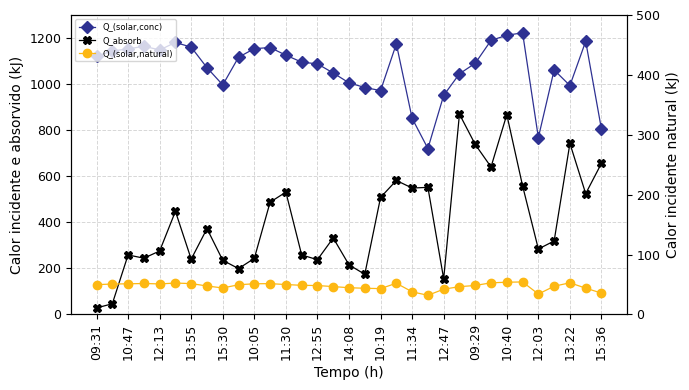

In [8]:
# === 1. Suavização (média móvel) ===
window = 1 # janela de suavização
df_c["Qsolar_smooth"] = df_c["Q_solar (kJ)"].rolling(window=window, center=True).mean()
df_c["Qab_smooth"] = df_c["Q_absorvido"].rolling(window=window, center=True).mean()
df_n["Qsolar_smooth"] = df_n["Q_solar (kJ)"].rolling(window=window, center=True).mean()


# === 2. Criar figura ===
fig, ax1 = plt.subplots(figsize=(7,4))

# === 3. Eixo primário (Concentrador) ===
ax1.plot(df_c["horas"], df_c["Qsolar_smooth"],label="Q_(solar,conc)",color="#2E3192", marker="D", linewidth=0.9)
ax1.plot(df_c["horas"], df_c["Qab_smooth"],label="Q_absorb",color="black", marker="X", linewidth=0.9)

ax1.set_xlabel("Tempo (h)", fontsize=10)
ax1.set_ylabel("Calor incidente e absorvido (kJ)", fontsize=10, color="black")
ax1.set_ylim(0, 1300)
ax1.tick_params(axis='x', rotation=90, labelsize=9)
ax1.tick_params(axis='y', labelsize=9)

# Grelhas mais espaçadas e suaves
ax1.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
#ax1.minorticks_on()
#ax1.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.3)

# === 4. Eixo secundário (Natural) ===
ax2 = ax1.twinx()
ax2.plot(df_n["horas"], df_n["Qsolar_smooth"],label="Q_(solar,natural)",color="#FDB813", marker="o", linewidth=0.9)
ax2.set_ylabel("Calor incidente natural (kJ)", fontsize=10, color="black")
ax2.set_ylim(0, 500)
ax2.tick_params(axis='y', labelsize=9)
ax2.set_xticks(df_c["horas"].iloc[::2])  # Pega de 2 em 2 registros

# === 5. Combinar legendas ===
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", fontsize=6)

# === 6. Estilo e título ===
# Ajuste final e exibição
plt.tight_layout()
fig.savefig("Calor incidente nos processos.png", dpi=300)
plt.show()

print('================Natural====================')
print(df_n['Q_solar (kJ)'].describe())

print('================Concentrador====================')
print(df_c['Q_solar (kJ)'].describe())

print('================Qabsorvido pelo concetrador=========')
print(df_c['Q_absorvido'].describe())

# GRAFICO IIII (calor util)

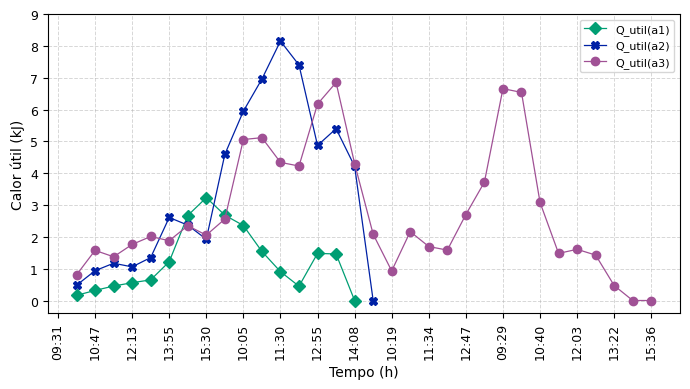

In [63]:
# === 1. Suavização (média móvel) ===
window = 2 # janela de suavização
df_c["Qu1_smooth"] = df_c["Q_util1 (kJ)"].rolling(window=window, center=True).mean()
df_c["Qu2_smooth"] = df_c["Q_util2 (kJ)"].rolling(window=window, center=True).mean()
df_c["Qu3_smooth"] = df_c["Q_util3 (kJ)"].rolling(window=window, center=True).mean()


# === 2. Criar figura ===
fig, ax1 = plt.subplots(figsize=(7,4))

# === 3. Eixo primário (Concentrador) ===
ax1.plot(df_c["horas"], df_c["Qu1_smooth"],label="Q_util(a1)",color="#009E73", marker="D", linewidth=0.9)
ax1.plot(df_c["horas"], df_c["Qu2_smooth"],label="Q_util(a2)",color="#0021A5", marker="X", linewidth=0.9)
ax1.plot(df_c["horas"], df_c["Qu3_smooth"],label="Q_util(a3)",color="#a05195", marker="o", linewidth=0.9)

ax1.set_xlabel("Tempo (h)", fontsize=10)
ax1.set_ylabel("Calor útil (kJ)", fontsize=10, color="black")
#ax1.set_ylim(0, None)
ax1.tick_params(axis='x', rotation=90, labelsize=9)
ax1.tick_params(axis='y', labelsize=9)

# === NOVO — Espaçamento de 1 em 1 no eixo Y ===
y_min = min(df_c["Qu1_smooth"].min(), df_c["Qu2_smooth"].min(), df_c["Qu3_smooth"].min())
y_max = max(df_c["Qu1_smooth"].max(), df_c["Qu2_smooth"].max(), df_c["Qu3_smooth"].max())
ax1.set_yticks(np.arange(y_min, y_max + 1, 1))


# Grelhas mais espaçadas e suaves
ax1.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
ax1.set_xticks(df_c["horas"].iloc[::2])  # Pega de 2 em 2 registros


# === 5. Combinar legendas ===
lines_1, labels_1 = ax1.get_legend_handles_labels()
ax1.legend(lines_1, labels_1, loc="upper right", fontsize=8)

# === 6. Estilo e título ===
# Ajuste final e exibição
plt.tight_layout()
fig.savefig("Calor util em tres galhos.png", dpi=300)
plt.show()

In [60]:
print(df_c['Q_util3 (kJ)'].describe())

count    33.000000
mean      2.683338
std       2.251283
min       0.000000
25%       1.302430
50%       2.049474
75%       3.700653
max       8.796294
Name: Q_util3 (kJ), dtype: float64


# GRAFICO V (Perdas no Sistemas)

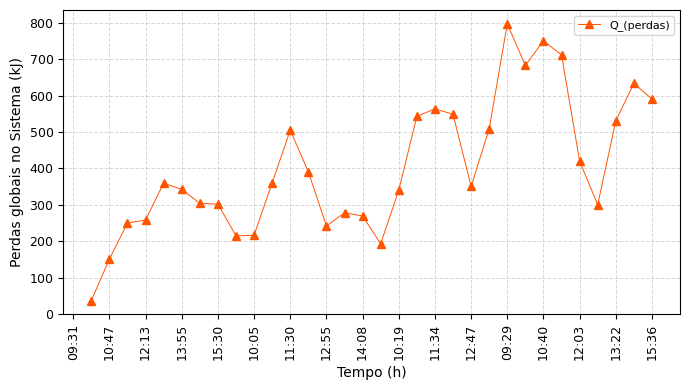

In [84]:
# === 1. Suavização (média móvel) ===
window = 2 # janela de suavização
df_c["Qperda_smooth"] = df_c["Q_perd (kJ)"].rolling(window=window, center=True).mean()

# === 2. Criar figura ===
fig, ax1 = plt.subplots(figsize=(7,4))

# === 3. Eixo primário (Concentrador) ===
ax1.plot(df_c["horas"], df_c["Qperda_smooth"],label="Q_(perdas)",color="#FF5400", marker="^", linewidth=0.7)

ax1.set_xlabel("Tempo (h)", fontsize=10)
ax1.set_ylabel("Perdas globais no Sistema (kJ)", fontsize=10, color="black")
#ax1.set_ylim(0, None)
ax1.tick_params(axis='x', rotation=90, labelsize=9)
ax1.tick_params(axis='y', labelsize=9)


# Grelhas mais espaçadas e suaves
ax1.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
ax1.set_xticks(df_c["horas"].iloc[::2])  # Pega de 2 em 2 registros


# === 5. Combinar legendas ===
lines_1, labels_1 = ax1.get_legend_handles_labels()
ax1.legend(lines_1, labels_1, loc="upper right", fontsize=8)

# === 6. Estilo e título ===
# Ajuste final e exibição
plt.tight_layout()
fig.savefig("Perdas No sistema.png", dpi=300)
plt.show()